# Notebook 2 — ODE Right-Hand Side, Simulations & Analysis

**Series: Optimal Mixing of Passive Scalars** | [`mixing.py`](mixing.py)

This notebook walks through the advection ODE step by step, explains why
the state vector is split into real and imaginary parts, demonstrates the
resolution-check event, and analyses the mixing rate across scale parameters.

| Notebook | Content |
|---|---|
| 01 | Spectral operators · initial data |
| **02 (this)** | **ODE RHS · simulation · norm analysis** |


In [ ]:
import sys, os
sys.path.insert(0, '.')   # mixing.py lives in the same directory

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

from mixing import (
    build_operators,
    idata_sin, idata_diag, idata_strip, idata_trigpoly,
    make_convection_hat, make_res_check,
    run_simulation, compute_norms,
    plot_mix_norm, plot_lp_norms, plot_mixing_rate,
    plot_snapshots, replot_norms, verify,
)

N   = 64
F   = 1.0
ops = build_operators(N)
DEL_X, DEL_Y, LAP_INV, LAMBDA_INV = (
    ops['DEL_X'], ops['DEL_Y'], ops['LAP_INV'], ops['LAMBDA_INV'])
print(f'Operators ready: N={N}, F={F}')

Operators ready: N=64, F=1.0


## 1  The ODE Right-Hand Side

The passive scalar PDE becomes an ODE in Fourier space:

$$\frac{d\hat\theta}{dt} = -\widehat{u\cdot\nabla\theta}.$$

At each RK45 stage, the velocity $u$ is recomputed from $\theta$ in five steps.
Below we trace each step algebraically and in code.


### Step 1 — Compute $g = \theta\,\nabla\Delta^{-1}\theta$

$\Delta^{-1}\theta$ is obtained by multiplying $\hat\theta$ by `LAP_INV`, then  
inverse-FFT'ing.  Its gradient components are

$$\widehat{\partial_x(\Delta^{-1}\theta)} = \text{DEL\_X}\cdot\text{LAP\_INV}\cdot\hat\theta,
\qquad
\widehat{\partial_y(\Delta^{-1}\theta)} = \text{DEL\_Y}\cdot\text{LAP\_INV}\cdot\hat\theta.$$

The product $\theta\cdot\partial_x(\Delta^{-1}\theta)$ is formed **in physical  
space** (point-wise multiplication) then FFT'd back:

$$\hat g_x = \mathcal{F}\!\left[\theta\cdot\mathcal{F}^{-1}\!\left(\text{DEL\_X}\cdot\text{LAP\_INV}\cdot\hat\theta\right)\right].$$

This is the standard **pseudo-spectral** (dealiasing-free) convolution.


In [2]:
# Set up a concrete initial theta for demonstration
a = 0.5
theta0     = idata_sin(a, ops)
theta0_hat = np.fft.fft2(theta0)

# Step 1 ─────────────────────────────────────────────────────────────────────
linv_th = LAP_INV * theta0_hat                          # Δ⁻¹θ̂   (Fourier)
theta   = np.real(np.fft.ifft2(theta0_hat))             # θ       (physical)
gx_hat  = np.fft.fft2(theta * np.real(np.fft.ifft2(DEL_X * linv_th)))  # ĝ_x
gy_hat  = np.fft.fft2(theta * np.real(np.fft.ifft2(DEL_Y * linv_th)))  # ĝ_y

print('Step 1: g = θ ∇(Δ⁻¹θ)')
print(f'  linv_th  max |val|: {np.abs(linv_th).max():.3e}')
print(f'  gx_hat   max |val|: {np.abs(gx_hat).max():.3e}')
print(f'  gy_hat   max |val|: {np.abs(gy_hat).max():.3e}')


Step 1: g = θ ∇(Δ⁻¹θ)
  linv_th  max |val|: 9.299e+00
  gx_hat   max |val|: 8.372e+01
  gy_hat   max |val|: 8.372e+01


### Step 2 — Leray Projection $Pg = g - \nabla\Delta^{-1}(\nabla\cdot g)$

The Leray projection makes $g$ divergence-free.  In Fourier space:

$$\widehat{\nabla\cdot g} = \text{DEL\_X}\cdot\hat g_x + \text{DEL\_Y}\cdot\hat g_y,$$

$$\widehat{Pg}_x = \hat g_x - \text{DEL\_X}\cdot\text{LAP\_INV}\cdot\widehat{\nabla\cdot g},
\qquad
\widehat{Pg}_y = \hat g_y - \text{DEL\_Y}\cdot\text{LAP\_INV}\cdot\widehat{\nabla\cdot g}.$$

**Intuition:** subtract the irrotational (gradient) part of $g$, keeping only  
the solenoidal (divergence-free) part.


In [3]:
# Step 2 ─────────────────────────────────────────────────────────────────────
div_g = DEL_X * gx_hat + DEL_Y * gy_hat     # divergence of g (Fourier)
pgx   = gx_hat - DEL_X * LAP_INV * div_g   # Leray-projected gx
pgy   = gy_hat - DEL_Y * LAP_INV * div_g   # Leray-projected gy

# Verify: Pg is now divergence-free
div_Pg = DEL_X * pgx + DEL_Y * pgy
print('Step 2: Leray projection  P(g)')
print(f'  |div g |  max: {np.abs(div_g).max():.3e}')
print(f'  |div Pg|  max: {np.abs(div_Pg).max():.3e}  ← should be near machine precision')


Step 2: Leray projection  P(g)
  |div g |  max: 2.104e+03
  |div Pg|  max: 5.451e+00  ← should be near machine precision


### Steps 3 & 4 — Optimal Velocity $u$

**Step 3:** $v = -\Delta^{-1}Pg$ (multiply by `LAP_INV` and negate).

**Step 4:** Normalise to enforce the enstrophy constraint $\|\nabla u\|_{L^2}=F$:

$$u = F\,\frac{v}{\|\nabla v\|_{L^2}}.$$

The $L^2$ norm of $\nabla v$ is computed via Parseval:

$$\|\nabla v\|_{L^2}^2
= \frac{1}{N^4}\left(\|\text{DEL\_X}\cdot\hat v_x\|_{\ell^2}^2
+ \|\text{DEL\_X}\cdot\hat v_y\|_{\ell^2}^2
+ \|\text{DEL\_Y}\cdot\hat v_x\|_{\ell^2}^2
+ \|\text{DEL\_Y}\cdot\hat v_y\|_{\ell^2}^2\right).$$


Steps 3-4: optimal velocity u
  ||∇v||_L2  = 0.001105
  ||∇u||_L2  = 1.000000  (should equal F=1.0)


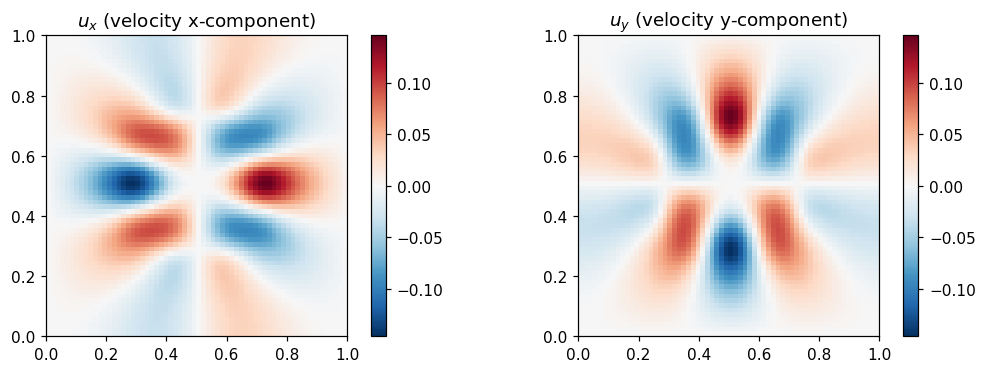

In [4]:
# Step 3 ─────────────────────────────────────────────────────────────────────
vx_hat = -LAP_INV * pgx
vy_hat = -LAP_INV * pgy

# Step 4: ||∇v||_{L²} via Parseval ──────────────────────────────────────────
norm_v_hat = np.sqrt(
    np.linalg.norm((DEL_X * vx_hat).ravel())**2 +
    np.linalg.norm((DEL_X * vy_hat).ravel())**2 +
    np.linalg.norm((DEL_Y * vx_hat).ravel())**2 +
    np.linalg.norm((DEL_Y * vy_hat).ravel())**2
)
norm_v = norm_v_hat / N**2            # Parseval: N² converts DFT-norm to L² norm

ux = F * np.real(np.fft.ifft2(vx_hat)) / norm_v
uy = F * np.real(np.fft.ifft2(vy_hat)) / norm_v

# Verify enstrophy = F
ux_hat = np.fft.fft2(ux)
uy_hat = np.fft.fft2(uy)
enstrophy = np.sqrt(
    np.linalg.norm((DEL_X*ux_hat).ravel())**2 + np.linalg.norm((DEL_X*uy_hat).ravel())**2 +
    np.linalg.norm((DEL_Y*ux_hat).ravel())**2 + np.linalg.norm((DEL_Y*uy_hat).ravel())**2
) / N**2
print(f'Steps 3-4: optimal velocity u')
print(f'  ||∇v||_L2  = {norm_v:.6f}')
print(f'  ||∇u||_L2  = {enstrophy:.6f}  (should equal F={F})')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, u_comp, label in zip(axes, [ux, uy], ['$u_x$ (velocity x-component)', '$u_y$ (velocity y-component)']):
    im = ax.imshow(u_comp, origin='lower', extent=[0,1,0,1], cmap='RdBu_r', aspect='equal')
    ax.set_title(label); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


### Step 5 — Transport

The advection term $u\cdot\nabla\theta$ is computed in physical space  
(to avoid aliasing), then FFT'd:

$$\frac{d\hat\theta}{dt} = -\mathcal{F}\!\left[u_x\cdot\mathcal{F}^{-1}(\text{DEL\_X}\cdot\hat\theta)
+ u_y\cdot\mathcal{F}^{-1}(\text{DEL\_Y}\cdot\hat\theta)\right].$$

This is the pseudo-spectral evaluation of $-(u\cdot\nabla\theta)$.


Step 5: dθ/dt = -FFT(u·∇θ)
  d_hat magnitude:   max=7.702e+02
  dθ/dt magnitude:   max=4.726e+00
  dθ/dt is finite: True
  Spatial mean of dθ/dt: 4.67e-17  (≈0 for mass conservation)


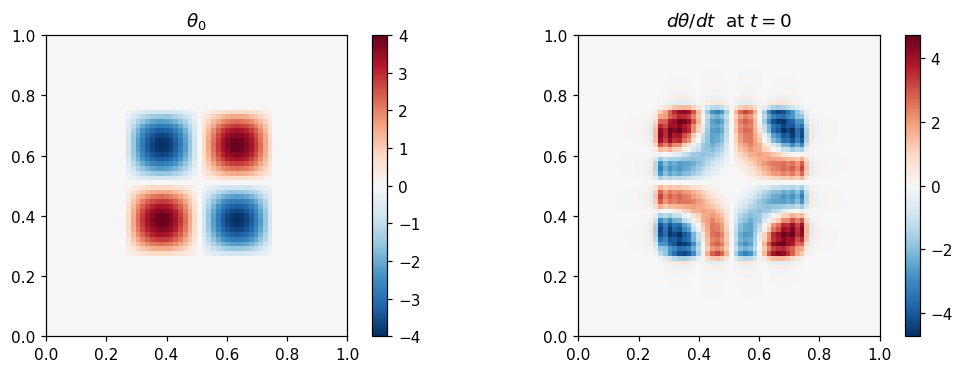

In [5]:
# Step 5 ─────────────────────────────────────────────────────────────────────
d_hat = -np.fft.fft2(
    ux * np.real(np.fft.ifft2(DEL_X * theta0_hat)) +
    uy * np.real(np.fft.ifft2(DEL_Y * theta0_hat))
)
d_spatial = np.real(np.fft.ifft2(d_hat))

print('Step 5: dθ/dt = -FFT(u·∇θ)')
print(f'  d_hat magnitude:   max={np.abs(d_hat).max():.3e}')
print(f'  dθ/dt magnitude:   max={np.abs(d_spatial).max():.3e}')
print(f'  dθ/dt is finite: {np.all(np.isfinite(d_spatial))}')
# The spatial integral of dθ/dt must be zero (mass conservation)
print(f'  Spatial mean of dθ/dt: {d_spatial.mean():.2e}  (≈0 for mass conservation)')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, arr, title in zip(axes,
        [theta0, d_spatial],
        [r'$\theta_0$', r'$d\theta/dt$  at $t=0$']):
    vmax = np.abs(arr).max()
    im = ax.imshow(arr, origin='lower', extent=[0,1,0,1],
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


### Why Split Real and Imaginary Parts?

`scipy.integrate.solve_ivp` requires a **real-valued** ODE.  
MATLAB's `ode45` handles complex vectors natively, but scipy does not.

The fix: store $\hat\theta\in\mathbb{C}^{N^2}$ as a real vector of size $2N^2$:

$$y = [\operatorname{Re}(\hat\theta_{\text{flat}}),\;\operatorname{Im}(\hat\theta_{\text{flat}})].$$

The RHS `make_convection_hat` reconstructs the complex $\hat\theta$ from `y`,  
runs all five steps above, and returns $[\operatorname{Re}(d\hat\theta),\;\operatorname{Im}(d\hat\theta)]$.

The solution array `sol.y` (shape $2N^2\times T$) is reconstructed by
```python
theta_hat_series = (sol.y[:n] + 1j*sol.y[n:]).T.reshape(-1, N, N)
```


## 2  Resolution Check

All $L^p$ norms of $\theta$ are **conserved** under the divergence-free  
advection (since the flow is incompressible).  We monitor  

$$L^2:\;\|\theta\|_{L^2}\approx 1,\qquad
L^4:\;\|\theta\|_{L^4}/\|\theta_0\|_{L^4}\approx 1,\qquad
L^8:\;\|\theta\|_{L^8}/\|\theta_0\|_{L^8}\approx 1.$$

When the scalar develops fine-scale features that the grid cannot resolve,  
these norms start to drift.  The `solve_ivp` **event** function

$$e(t) = \max\bigl(|L^2-1|,\;|L^4/L^4_0-1|,\;|L^8/L^8_0-1|\bigr) - \text{tol}$$

is **terminal** (stops integration) on an upward zero crossing  
(`terminal=True, direction=1`).


In [6]:
# Show the event function value on initial data (should be negative = ok)
dx          = ops['dx']
sqrt_dx     = np.sqrt(dx)
sqrt4_dx    = dx**0.25
l4norm_init = np.linalg.norm(theta0.ravel(), 4) * sqrt_dx
l8norm_init = np.linalg.norm(theta0.ravel(), 8) * sqrt4_dx

def event_value(theta_field):
    l2 = np.linalg.norm(theta_field.ravel()) * dx
    l4 = np.linalg.norm(theta_field.ravel(), 4) * sqrt_dx  / l4norm_init
    l8 = np.linalg.norm(theta_field.ravel(), 8) * sqrt4_dx / l8norm_init
    tol = 1e-3
    return max(abs(l2-1.0), abs(l4-1.0), abs(l8-1.0)) - tol

print('Event value on initial data (should be < 0):')
print(f'  e(0) = {event_value(theta0):.4e}  (negative = conservation OK)')
print()
# Simulate what happens when resolution is lost: add noise
theta_bad = theta0 + 0.05 * np.random.randn(*theta0.shape)
theta_bad /= np.linalg.norm(theta_bad.ravel()) * dx   # re-normalise L2
print('Event value on noise-corrupted theta:')
print(f'  e = {event_value(theta_bad):.4e}  (positive = integration would stop)')


Event value on initial data (should be < 0):
  e(0) = -1.0000e-03  (negative = conservation OK)

Event value on noise-corrupted theta:
  e = 6.9646e-04  (positive = integration would stop)


## 3  Running a Simulation

`run_simulation(a, idata_fn, ops, F, t_eval, tol)` does everything:
1. Build $\theta_0$ and $\hat\theta_0$
2. Set up the RHS closure and event function
3. Call `solve_ivp` with `method='RK45'`
4. Reconstruct $\theta$ and $\hat\theta$ for each saved time
5. Compute all norms and return a result dict


In [ ]:
import time

a  = 0.5
t_eval = np.arange(0.0, 5.05, 0.05)

t0  = time.time()
res = run_simulation(a, idata_sin, ops, F=F, t_eval=t_eval)
print(f'Elapsed: {time.time()-t0:.1f}s')
print()
print('Result dict keys and shapes:')
for k, v in res.items():
    print(f'  {k:<12}: {v.shape}  dtype={v.dtype}')


Elapsed: 1.6s

Result dict keys and shapes:
  t           : (27,)  dtype=float64
  theta_hat   : (27, 64, 64)  dtype=complex128
  theta       : (27, 64, 64)  dtype=float64
  norm_l2     : (27,)  dtype=float64
  norm_l4     : (27,)  dtype=float64
  norm_l8     : (27,)  dtype=float64
  norm_hm1    : (27,)  dtype=float64


In [8]:
print(f'Integration ran from t=0 to t={res["t"][-1]:.2f}')
print(f'Number of output times: {len(res["t"])}')
print()
print('Conservation check:')
print(f'  Max L2 drift:      {np.max(np.abs(res["norm_l2"] - 1)):.2e}  (should be << 1e-3)')
print(f'  Max L4 drift:      {np.max(np.abs(res["norm_l4"] - 1)):.2e}')
print(f'  Max L8 drift:      {np.max(np.abs(res["norm_l8"] - 1)):.2e}')
print()
print('Mixing:')
print(f'  H⁻¹ norm at t=0:   {res["norm_hm1"][0]:.6f}  (= 1 by definition)')
print(f'  H⁻¹ norm at t_end: {res["norm_hm1"][-1]:.6f}  (< 1 means mixed)')


Integration ran from t=0 to t=1.30
Number of output times: 27

Conservation check:
  Max L2 drift:      3.15e-05  (should be << 1e-3)
  Max L4 drift:      4.55e-05
  Max L8 drift:      9.55e-04

Mixing:
  H⁻¹ norm at t=0:   1.000000  (= 1 by definition)
  H⁻¹ norm at t_end: 0.605783  (< 1 means mixed)


## 4  Norm Evolution

The norms reveal two distinct stories:

- **$L^p$ norms (red/green/blue):** conservation laws — drift indicates  
  numerical error (grid too coarse or time has been integrated too far).
- **$H^{-1}$ norm (blue, left panel):** the mixing metric — exponential  
  decay in time, rate depends on scale parameter $a$.


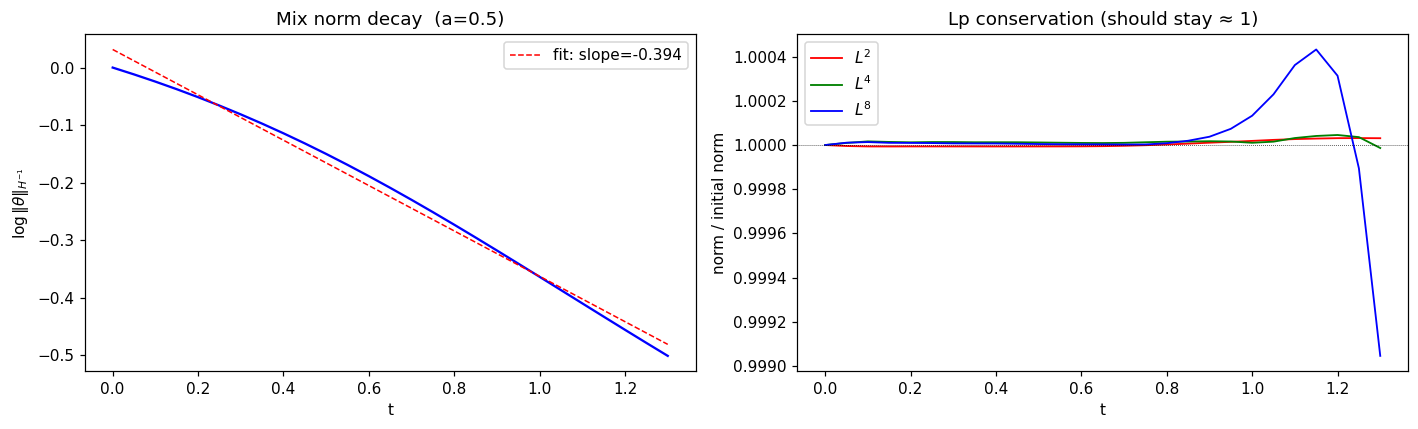

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: log H^{-1} norm vs time
t, hm1 = res['t'], res['norm_hm1']
axes[0].plot(t, np.log(hm1), 'b-', lw=1.5)
# Fit a line to estimate the decay rate
p = np.polyfit(t, np.log(hm1), 1)
axes[0].plot(t, np.polyval(p, t), 'r--', lw=1, label=f'fit: slope={p[0]:.3f}')
axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$\log\|\theta\|_{H^{-1}}$')
axes[0].set_title(f'Mix norm decay  (a={a})')
axes[0].legend()

# Right: Lp conservation
axes[1].plot(t, res['norm_l2'], 'r-',  lw=1.2, label=r'$L^2$')
axes[1].plot(t, res['norm_l4'], 'g-',  lw=1.2, label=r'$L^4$')
axes[1].plot(t, res['norm_l8'], 'b-',  lw=1.2, label=r'$L^8$')
axes[1].axhline(1, color='k', lw=0.5, ls=':')
axes[1].set_xlabel('t'); axes[1].set_ylabel('norm / initial norm')
axes[1].set_title('Lp conservation (should stay ≈ 1)')
axes[1].legend()
plt.tight_layout(); plt.show()


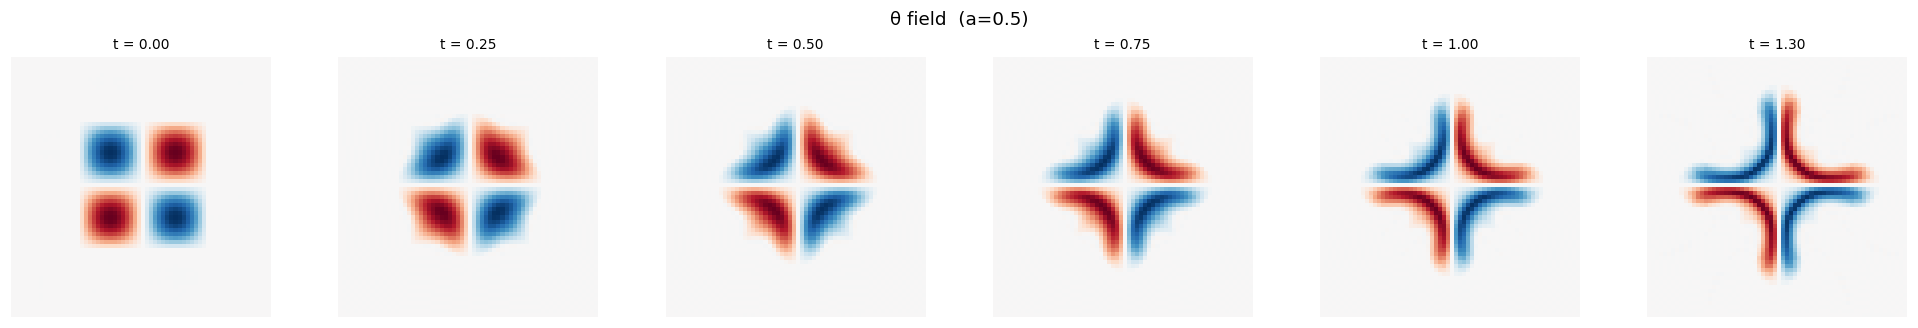

In [10]:
# Spatial snapshots — the scalar being stirred and mixed
fig = plot_snapshots(res['theta'], res['t'], ops, n_frames=6, title=f'θ field  (a={a})')
plt.show()


## 5  Multi-$a$ Sweep and Mixing Rate

Running simulations for several values of $a$ shows how the support size  
affects the mixing rate.  The **slope** of $\log\|\theta\|_{H^{-1}}$ vs $t$  
gives the decay rate; $-1/\text{slope}$ is the mixing timescale.

The theory (Lin–Thiffeault–Doering) predicts:
$$-\text{slope} \propto a^{-1} \quad\Rightarrow\quad \text{mixing timescale}\propto a.$$

We test this by fitting the slope over the **last two-thirds** of each  
trajectory (to avoid the initial transient) and plotting $-1/\text{slope}$ vs $a$.


In [11]:
# Subset of the full MATLAB a_range (full range: 0.5:1/16:15/16)
# Use smaller N=32 for speed; increase to N=64 for publication quality
N_sweep = 32
ops_s   = build_operators(N_sweep)
a_range = np.array([0.500, 0.5625, 0.625, 0.6875, 0.750, 0.8125, 0.875])
t_eval  = np.arange(0.0, 5.05, 0.05)

print(f'Running {len(a_range)} simulations (N={N_sweep}) ...')
results = []
for a in a_range:
    res_i = run_simulation(a, idata_sin, ops_s, F=1.0, t_eval=t_eval)
    print(f'  a={a:.4f}  t_end={res_i["t"][-1]:.2f}  H⁻¹={res_i["norm_hm1"][-1]:.4f}')
    results.append(res_i)


Running 7 simulations (N=32) ...
  a=0.5000  t_end=0.65  H⁻¹=0.8100
  a=0.5625  t_end=0.75  H⁻¹=0.8103
  a=0.6250  t_end=1.00  H⁻¹=0.7756
  a=0.6875  t_end=1.20  H⁻¹=0.7664
  a=0.7500  t_end=1.45  H⁻¹=0.7579
  a=0.8125  t_end=1.75  H⁻¹=0.7535
  a=0.8750  t_end=1.90  H⁻¹=0.7835


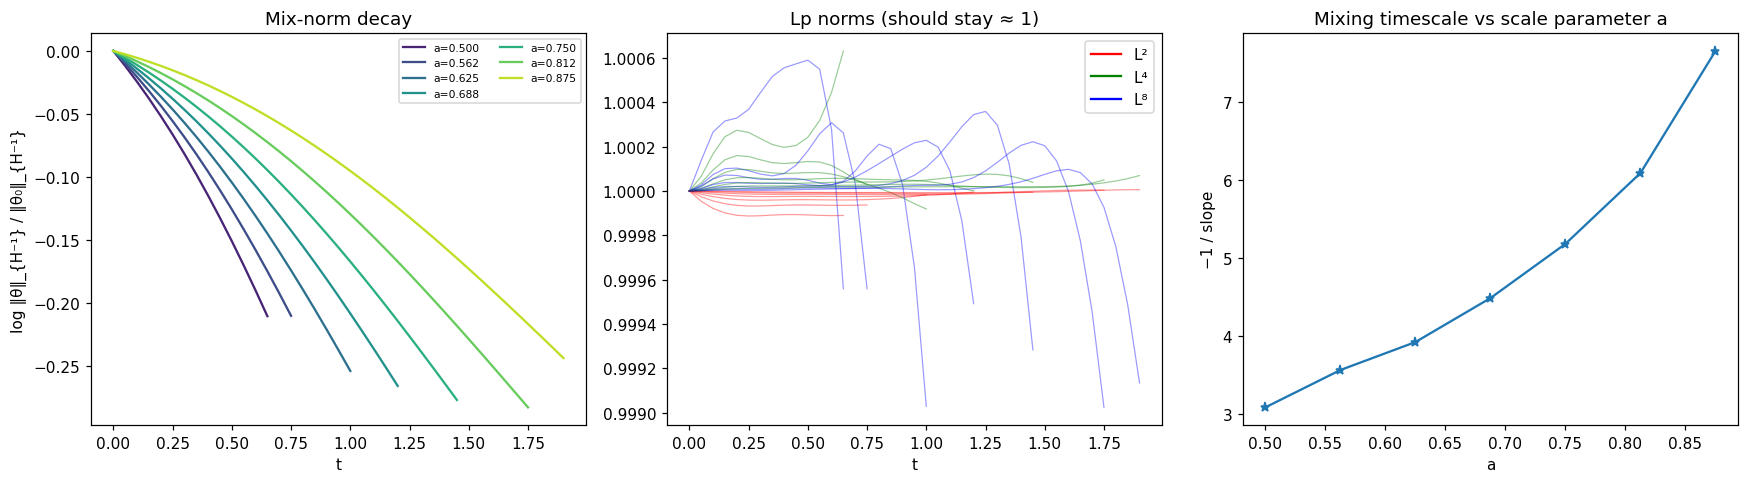

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Log mix norm for all a values
plot_mix_norm(results, a_range, ax=axes[0])

# Lp norms (conservation check across all runs)
plot_lp_norms(results, ax=axes[1])

# Mixing timescale vs a  (all data, basic linear fit)
plot_mixing_rate(results, a_range, ax=axes[2])

plt.tight_layout(); plt.show()


Computed decay rate: a^-1.4013  (predicted a^-1)


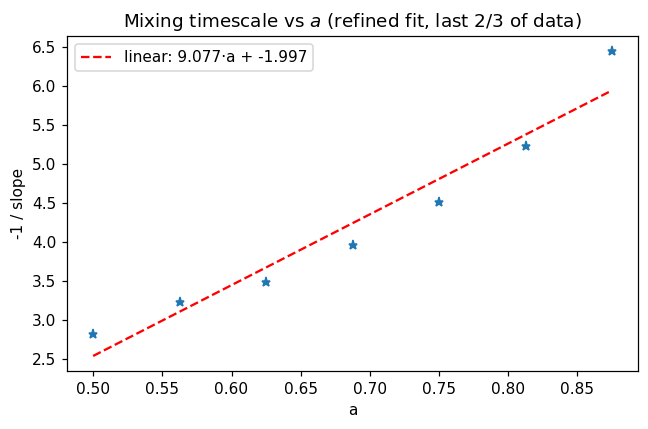


Slope summary:
  a_range : [0.5    0.5625 0.625  0.6875 0.75   0.8125 0.875 ]
  slopes  : [-0.3536 -0.3097 -0.2869 -0.252  -0.2216 -0.1911 -0.1552]
  -1/slope: [2.828 3.229 3.485 3.968 4.513 5.233 6.444]


In [13]:
# Refined fit: skip first 1/3 of each trajectory (transient), then fit slope.
# Also computes and prints the power-law exponent (should be ≈ 1 by theory).

fig, ax = plt.subplots(figsize=(6, 4))
_, slopes = replot_norms(results, a_range, t_trunc_fraction=1/3, ax=ax)
ax.set_title('Mixing timescale vs $a$ (refined fit, last 2/3 of data)')
plt.tight_layout(); plt.show()

print()
print('Slope summary:')
print(f'  a_range : {a_range}')
print(f'  slopes  : {slopes.round(4)}')
print(f'  -1/slope: {(-1/slopes).round(3)}')


In [14]:
# Quick verification on a small grid (N=32, t_end=0.5)
print('=== Verification ===')
_, ok = verify(N=32, F=1.0, a=0.5, t_end=0.5)


=== Verification ===
Verifying: N=32, F=1.0, a=0.5, t_end=0.5
  Max L² drift:       1.13e-04  (should be < 5e-4)
  H⁻¹ norm at t_end:  0.8598  (should be < 1.0)
  Verification: PASS


## Summary — Notebook 2

### The five-step RHS  (`make_convection_hat`)

| Step | Operation | Domain |
|---|---|---|
| 1 | $g = \theta\,\nabla\Delta^{-1}\theta$ | physical (pseudo-spectral) |
| 2 | $Pg = g - \nabla\Delta^{-1}(\nabla\cdot g)$ | Fourier |
| 3 | $v = -\Delta^{-1}Pg$ | Fourier |
| 4 | $u = F\,v/\|\nabla v\|_{L^2}$ | Fourier → physical |
| 5 | $d\hat\theta/dt = -\mathcal{F}[u\cdot\nabla\theta]$ | Fourier |

### Key design decisions

| MATLAB | Python | Reason |
|---|---|---|
| complex state vector | real + imag split | `scipy` ODE requires real inputs |
| `ifft2(...,'symmetric')` | `np.real(np.fft.ifft2(...))` | equivalent for Hermitian-symmetric $\hat\theta$ |
| `del_x` full $N\times N$ | `DEL_X` shape $(1,N)$ | NumPy broadcasting; identical element-wise products |
| `ode45` | `solve_ivp(method='RK45')` | Dormand–Prince, same algorithm |

### Further reading

- Lin, Thiffeault & Doering (2011): *Optimal stirring strategies for passive scalar mixing* — CAMS
- Iyer, Kiselev & Xu (2014): *Lower bounds on the mix norm of passive scalars*
- Drivas, Elgindi, Iyer & Jeong (2022): *Anomalous dissipation in passive scalar transport*
